# Match Analysis

Comprehensive analysis of match performance data across the 2025–26 OH Leuven season.

**Data source:** `data/processed/RTT.xlsx` — match performance columns are shifted +1 day, so a row on date `t` carries performance from the match played on `t-1`.

**Key variables:**
- `Match HID Per BIP Yesterday` — High-Intensity Distance (m) per Ball-In-Play minute
- `Match HIE Per BIP Yesterday` — High-Intensity Efforts (count) per Ball-In-Play minute
- `Match Minutes Played Yesterday` — Minutes played in the match

**Why Per-BIP?**  
Raw distance and effort counts are heavily confounded by playing time. Normalising by Ball-In-Play minutes controls for both total minutes played and the proportion of time the ball is actually in play, giving a fairer intensity measure across substitutes vs. full-game players.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'RTT.xlsx'

# ── style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

# ── colour palette ─────────────────────────────────────────────────────────────
C_HID  = '#1f77b4'   # blue  — HID Per BIP
C_HIE  = '#d62728'   # red   — HIE Per BIP
C_MIN  = '#2ca02c'   # green — Minutes Played
C_MI   = '#9467bd'   # purple — Match Intensity
C_GREY = '#7f7f7f'

POSITION_COLORS = {
    'CD':  '#1f77b4',
    'FB':  '#aec7e8',
    'CDM': '#2ca02c',
    'WB':  '#98df8a',
    'CAM': '#ff7f0e',
    'WG':  '#ffbb78',
    'ST':  '#d62728',
}

# ── load data ──────────────────────────────────────────────────────────────────
df = pd.read_excel(DATA_PATH, parse_dates=['Date'])
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')

# Rows where match performance data is available
PERF = df[df['Match HID Per BIP Yesterday'].notna()].copy()
# Recover match date (data is shifted +1 day)
PERF['Match Date'] = PERF['Date'] - pd.Timedelta(days=1)

HID_COL = 'Match HID Per BIP Yesterday'
HIE_COL = 'Match HIE Per BIP Yesterday'
MIN_COL = 'Match Minutes Played Yesterday'
MI_COL  = 'Match Intensity Yesterday'

print(f'Performance rows: {len(PERF):,}  |  Players: {PERF["Player ID"].nunique()}  |  Matches: {PERF["Match Date"].nunique()}')

Loaded 5,234 rows × 46 columns
Performance rows: 362  |  Players: 23  |  Matches: 25


---
## 1  Dataset Overview

In [2]:
# ── summary table ──────────────────────────────────────────────────────────────
match_dates = sorted(PERF['Match Date'].unique())
summary = pd.DataFrame({
    'Metric': [
        'Total matches in dataset',
        'Total player-match observations',
        'Players with match data',
        'Season span',
        'Avg players per match',
        'Avg minutes played',
        'Avg HID Per BIP (m)',
        'Avg HIE Per BIP',
    ],
    'Value': [
        len(match_dates),
        len(PERF),
        PERF['Player ID'].nunique(),
        f"{pd.Timestamp(match_dates[0]).strftime('%b %d %Y')} – {pd.Timestamp(match_dates[-1]).strftime('%b %d %Y')}",
        f"{PERF.groupby('Match Date').size().mean():.1f}",
        f"{PERF[MIN_COL].mean():.1f}",
        f"{PERF[HID_COL].mean():.1f}",
        f"{PERF[HIE_COL].mean():.3f}",
    ]
})
print(summary.to_string(index=False))

print()
print('Descriptive statistics:')
print(PERF[[HID_COL, HIE_COL, MIN_COL]].describe().round(2).to_string())

                         Metric                     Value
       Total matches in dataset                        25
Total player-match observations                       362
        Players with match data                        23
                    Season span Jul 27 2025 – Feb 14 2026
          Avg players per match                      14.5
             Avg minutes played                      68.2
            Avg HID Per BIP (m)                      18.8
                Avg HIE Per BIP                     1.018

Descriptive statistics:
       Match HID Per BIP Yesterday  Match HIE Per BIP Yesterday  Match Minutes Played Yesterday
count                       362.00                       362.00                          362.00
mean                         18.80                         1.02                           68.18
std                           7.83                         0.37                           31.92
min                           6.08                         0.31      

---
## 2  Match Calendar

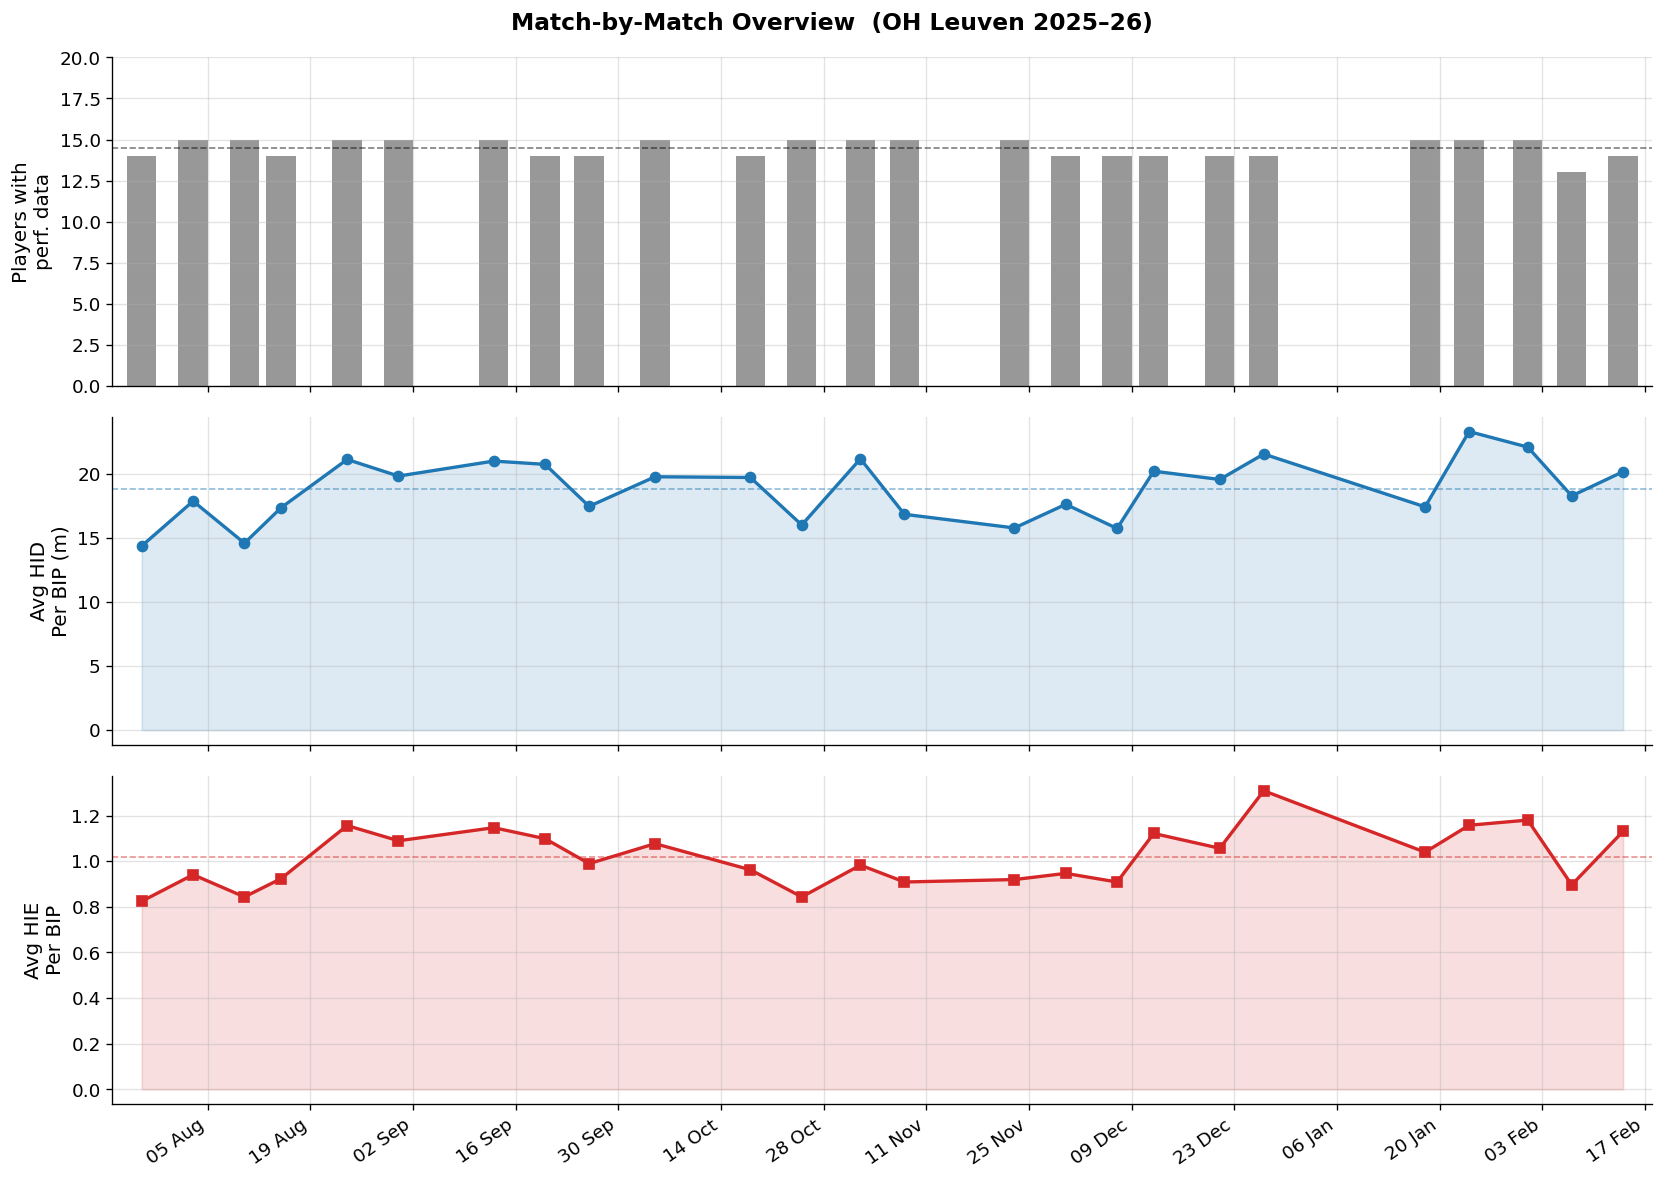

Match schedule:
Match Date  n_players   avg_hid  avg_hie   avg_min
2025-07-27         14 14.384286 0.824286 70.478571
2025-08-03         15 17.881333 0.940667 61.490000
2025-08-10         15 14.598667 0.843333 67.191333
2025-08-15         14 17.370000 0.923571 72.168571
2025-08-24         15 21.136000 1.156000 65.035333
2025-08-31         15 19.838667 1.089333 64.853333
2025-09-13         15 21.010000 1.146667 65.620000
2025-09-20         14 20.752143 1.098571 72.514286
2025-09-26         14 17.475000 0.989286 69.428571
2025-10-05         15 19.786000 1.076667 66.453333
2025-10-18         14 19.727143 0.962143 69.250714
2025-10-25         15 16.018667 0.843333 65.913333
2025-11-02         15 21.188000 0.982667 65.253333
2025-11-08         15 16.852667 0.908667 64.350667
2025-11-23         15 15.786000 0.919333 66.460667
2025-11-30         14 17.632857 0.946429 68.072143
2025-12-07         14 15.746429 0.908571 64.639286
2025-12-12         14 20.220714 1.121429 72.188571
2025-12-21     

In [3]:
# ── per-match player counts and average performance ────────────────────────────
match_summary = (
    PERF.groupby('Match Date')
    .agg(
        n_players=('Player ID', 'count'),
        avg_hid=(HID_COL, 'mean'),
        avg_hie=(HIE_COL, 'mean'),
        avg_min=(MIN_COL, 'mean'),
    )
    .reset_index()
    .sort_values('Match Date')
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Match-by-Match Overview  (OH Leuven 2025–26)', fontsize=14, fontweight='bold', y=0.98)

x = match_summary['Match Date']

# Panel 1: players per match
ax = axes[0]
ax.bar(x, match_summary['n_players'], color=C_GREY, width=4, alpha=0.8, label='Players with data')
ax.set_ylabel('Players with\nperf. data')
ax.set_ylim(0, 20)
ax.axhline(match_summary['n_players'].mean(), color='black', lw=1, ls='--', alpha=0.5)

# Panel 2: avg HID per BIP
ax = axes[1]
ax.plot(x, match_summary['avg_hid'], color=C_HID, marker='o', ms=6, lw=2)
ax.fill_between(x, match_summary['avg_hid'], alpha=0.15, color=C_HID)
ax.set_ylabel('Avg HID\nPer BIP (m)')
ax.axhline(match_summary['avg_hid'].mean(), color=C_HID, lw=1, ls='--', alpha=0.5)

# Panel 3: avg HIE per BIP
ax = axes[2]
ax.plot(x, match_summary['avg_hie'], color=C_HIE, marker='s', ms=6, lw=2)
ax.fill_between(x, match_summary['avg_hie'], alpha=0.15, color=C_HIE)
ax.set_ylabel('Avg HIE\nPer BIP')
ax.axhline(match_summary['avg_hie'].mean(), color=C_HIE, lw=1, ls='--', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=35, ha='right')

for ax in axes:
    ax.set_xlim(x.min() - pd.Timedelta(days=4), x.max() + pd.Timedelta(days=4))

plt.tight_layout()
plt.show()

print('Match schedule:')
print(match_summary[['Match Date', 'n_players', 'avg_hid', 'avg_hie', 'avg_min']].to_string(index=False))

---
## 3  Distributions

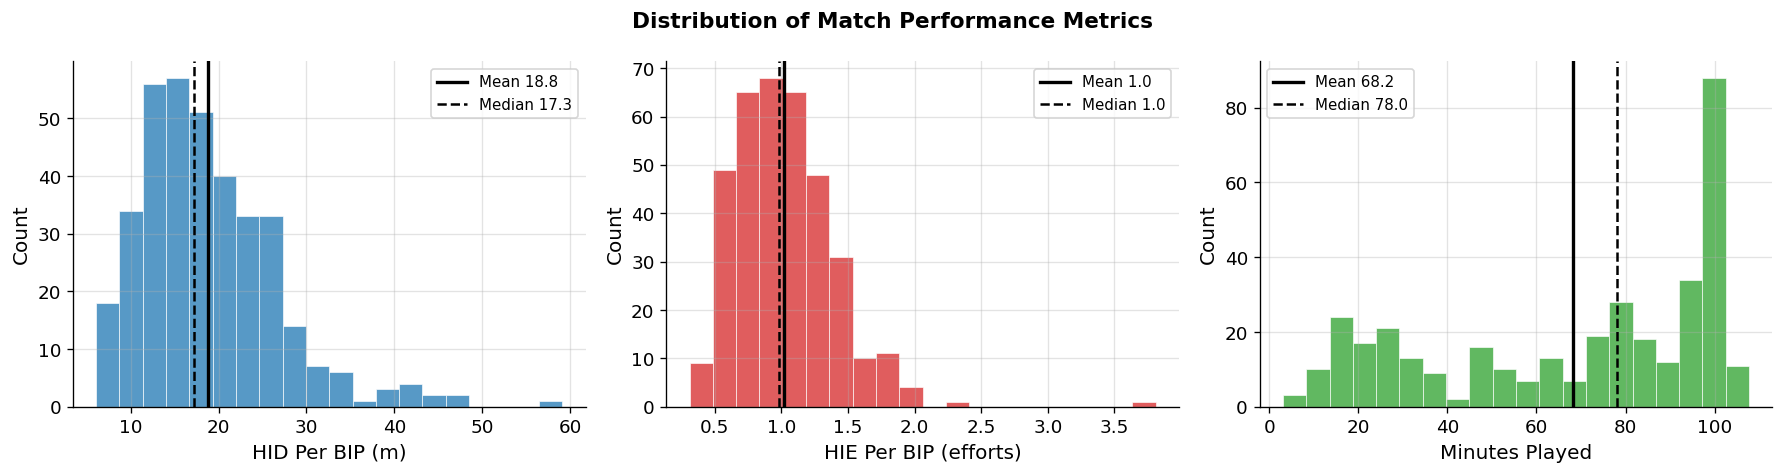

Shapiro–Wilk normality tests (p < 0.05 → reject normality):
  HID Per BIP (m)                 W=0.9221  p=0.0000  NOT normal
  HIE Per BIP (efforts)           W=0.9181  p=0.0000  NOT normal
  Minutes Played                  W=0.8738  p=0.0000  NOT normal


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribution of Match Performance Metrics', fontsize=13, fontweight='bold')

configs = [
    (HID_COL, 'HID Per BIP (m)',          C_HID,  20),
    (HIE_COL, 'HIE Per BIP (efforts)',     C_HIE,  20),
    (MIN_COL, 'Minutes Played',            C_MIN,  20),
]

for ax, (col, label, color, bins) in zip(axes, configs):
    data = PERF[col].dropna()
    ax.hist(data, bins=bins, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(),   color='black', lw=2,   ls='-',  label=f'Mean {data.mean():.1f}')
    ax.axvline(data.median(), color='black', lw=1.5, ls='--', label=f'Median {data.median():.1f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Normality tests
print('Shapiro–Wilk normality tests (p < 0.05 → reject normality):')
for col, label, *_ in configs:
    stat, p = stats.shapiro(PERF[col].dropna())
    print(f'  {label:<30}  W={stat:.4f}  p={p:.4f}  {"normal" if p > 0.05 else "NOT normal"}')

---
## 4  Scatter Plots — HID, HIE, and Minutes Played

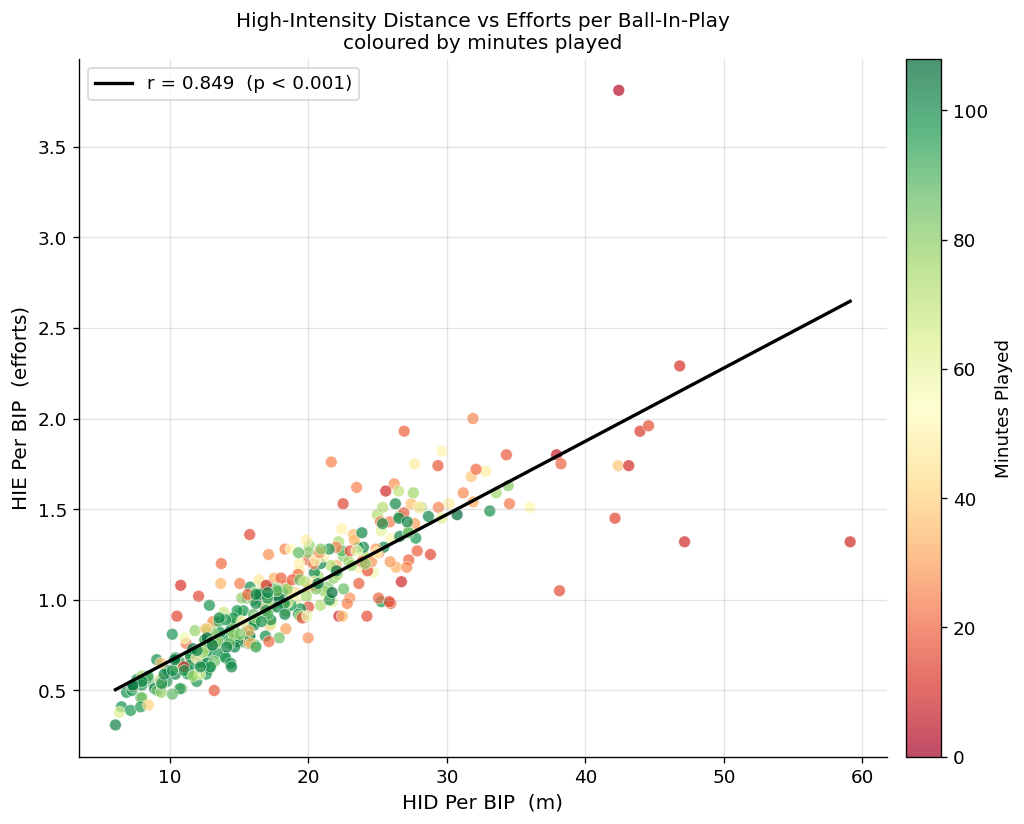

Pearson r (HID vs HIE):  r = 0.8495,  p = 5.42e-102,  R² = 0.7216
Regression:  HIE = 0.0404 × HID + 0.2589


In [5]:
# ── Main scatter: HID vs HIE, sized and coloured by minutes ───────────────────
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    PERF[HID_COL], PERF[HIE_COL],
    c=PERF[MIN_COL], cmap='RdYlGn', vmin=0, vmax=108,
    s=50, alpha=0.7, edgecolors='white', linewidths=0.4,
)

# regression line
slope, intercept, r, p, se = stats.linregress(PERF[HID_COL], PERF[HIE_COL])
x_line = np.linspace(PERF[HID_COL].min(), PERF[HID_COL].max(), 200)
ax.plot(x_line, slope * x_line + intercept, color='black', lw=2,
        label=f'r = {r:.3f}  (p < 0.001)')

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Minutes Played', fontsize=11)

ax.set_xlabel('HID Per BIP  (m)')
ax.set_ylabel('HIE Per BIP  (efforts)')
ax.set_title('High-Intensity Distance vs Efforts per Ball-In-Play\n'
             'coloured by minutes played', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Pearson r (HID vs HIE):  r = {r:.4f},  p = {p:.2e},  R² = {r**2:.4f}')
print(f'Regression:  HIE = {slope:.4f} × HID + {intercept:.4f}')

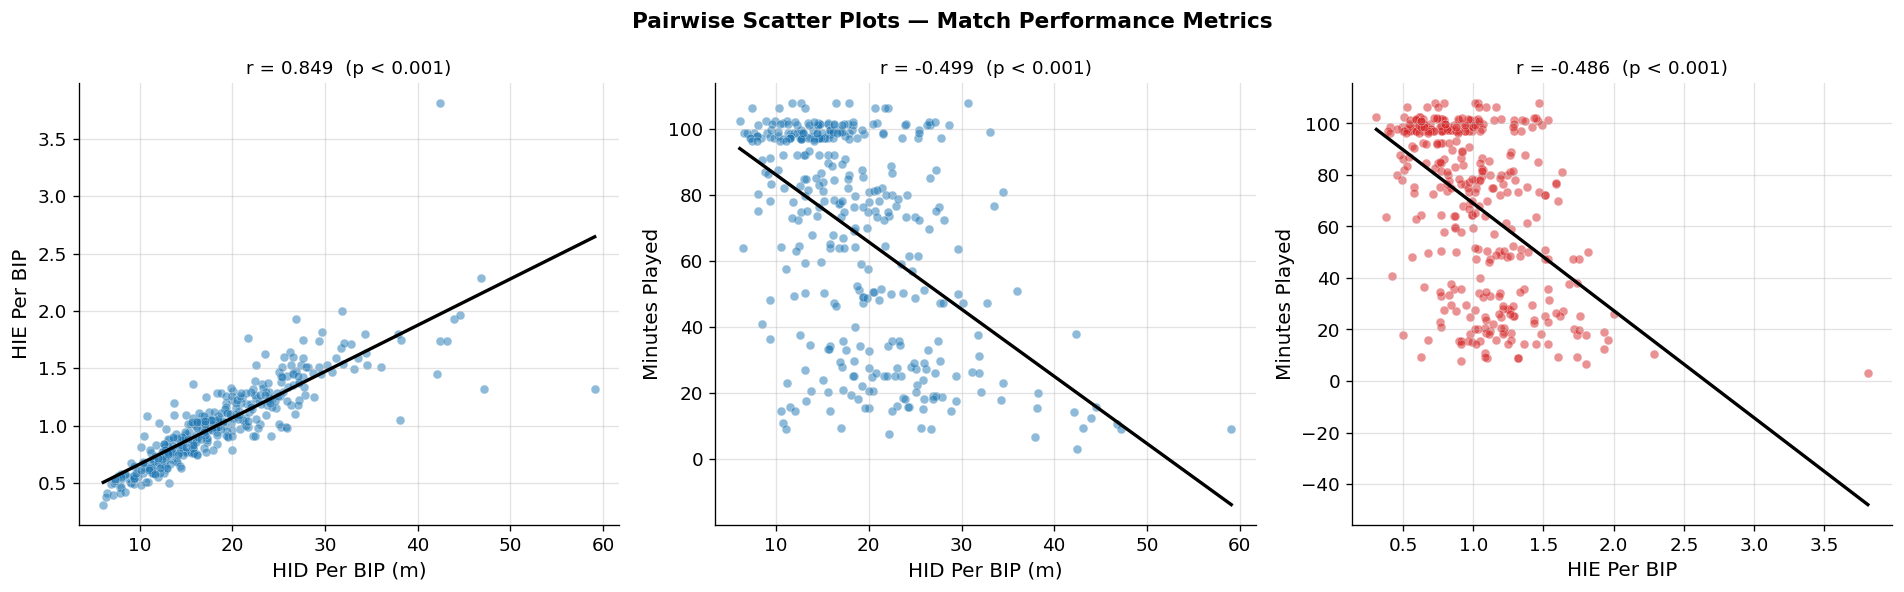

In [6]:
# ── 2×2 scatter grid ──────────────────────────────────────────────────────────
pairs = [
    (HID_COL, HIE_COL,  'HID Per BIP (m)',  'HIE Per BIP',       C_HID),
    (HID_COL, MIN_COL,  'HID Per BIP (m)',  'Minutes Played',    C_HID),
    (HIE_COL, MIN_COL,  'HIE Per BIP',      'Minutes Played',    C_HIE),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Pairwise Scatter Plots — Match Performance Metrics', fontsize=13, fontweight='bold')

for ax, (xcol, ycol, xlabel, ylabel, color) in zip(axes, pairs):
    x_data = PERF[xcol].dropna()
    y_data = PERF[ycol].loc[x_data.index]
    mask = x_data.notna() & y_data.notna()
    x_d, y_d = x_data[mask], y_data[mask]

    ax.scatter(x_d, y_d, color=color, alpha=0.5, s=28, edgecolors='white', linewidths=0.3)

    slope, intercept, r, p, _ = stats.linregress(x_d, y_d)
    x_line = np.linspace(x_d.min(), x_d.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, color='black', lw=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    p_str = f'{p:.3f}' if p >= 0.001 else 'p < 0.001'
    ax.set_title(f'r = {r:.3f}  ({p_str})', fontsize=11)

plt.tight_layout()
plt.show()

---
## 5  Correlation Analysis

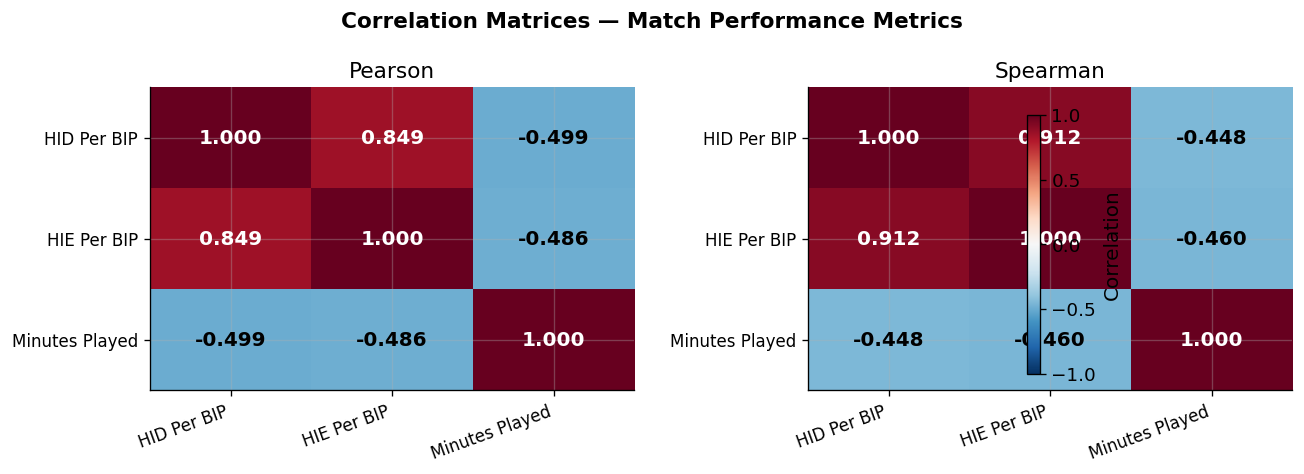

Pearson correlations with p-values:
  HID Per BIP × HIE Per BIP           r=+0.8495  p=5.42e-102
  HID Per BIP × Minutes Played        r=-0.4994  p=3.12e-24
  HIE Per BIP × Minutes Played        r=-0.4856  p=8.10e-23


In [7]:
import matplotlib.cm as cm

corr_cols = [HID_COL, HIE_COL, MIN_COL]
corr_labels = ['HID Per BIP', 'HIE Per BIP', 'Minutes Played']

# Pearson and Spearman
pearson  = PERF[corr_cols].corr(method='pearson')
spearman = PERF[corr_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Correlation Matrices — Match Performance Metrics', fontsize=13, fontweight='bold')

for ax, corr_mat, title in zip(axes, [pearson, spearman], ['Pearson', 'Spearman']):
    im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(corr_labels, rotation=20, ha='right', fontsize=10)
    ax.set_yticklabels(corr_labels, fontsize=10)
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{corr_mat.values[i, j]:.3f}',
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    color='white' if abs(corr_mat.values[i, j]) > 0.5 else 'black')

fig.colorbar(im, ax=axes, shrink=0.7, pad=0.02, label='Correlation')
plt.tight_layout()
plt.show()

# Significance
print('Pearson correlations with p-values:')
for i, c1 in enumerate(corr_cols):
    for j, c2 in enumerate(corr_cols):
        if j > i:
            r, p = stats.pearsonr(PERF[c1], PERF[c2])
            print(f'  {corr_labels[i]} × {corr_labels[j]:20}  r={r:+.4f}  p={p:.2e}')

---
## 6  Minutes Played — Effect on Per-BIP Metrics

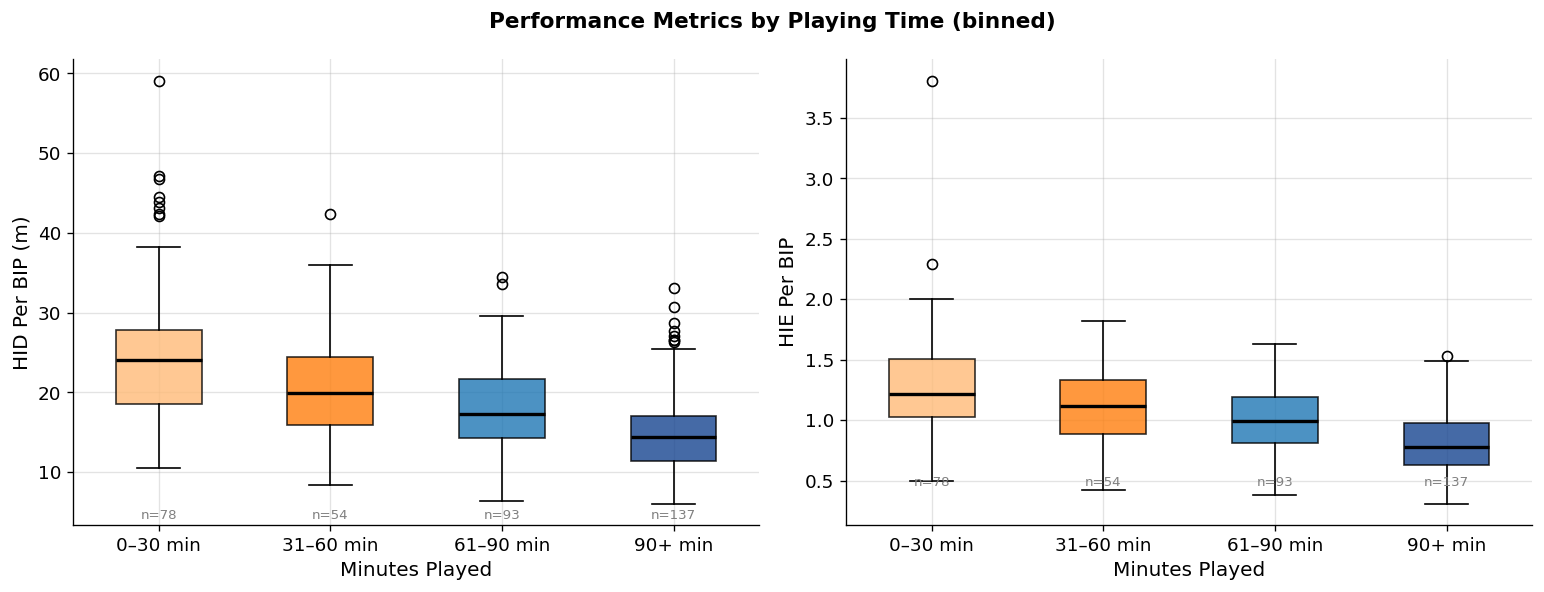

Kruskal–Wallis HID Per BIP: H=85.95, p=0.0000
Kruskal–Wallis HIE Per BIP: H=91.73, p=0.0000


In [8]:
# Bin by playing time
PERF['Minutes Bin'] = pd.cut(
    PERF[MIN_COL],
    bins=[0, 30, 60, 90, 120],
    labels=['0–30 min', '31–60 min', '61–90 min', '90+ min'],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Performance Metrics by Playing Time (binned)', fontsize=13, fontweight='bold')

bin_order = ['0–30 min', '31–60 min', '61–90 min', '90+ min']
colors_bins = ['#ffbb78', '#ff7f0e', '#1f77b4', '#174590']

for ax, (col, label, color) in zip(axes, [
    (HID_COL, 'HID Per BIP (m)',    C_HID),
    (HIE_COL, 'HIE Per BIP',        C_HIE),
]):
    groups = [PERF[PERF['Minutes Bin'] == b][col].dropna() for b in bin_order]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'lw': 2})
    for patch, c in zip(bp['boxes'], colors_bins):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    ax.set_xticklabels(bin_order)
    ax.set_xlabel('Minutes Played')
    ax.set_ylabel(label)
    # sample sizes
    for k, g in enumerate(groups):
        ax.text(k + 1, ax.get_ylim()[0] + 0.3, f'n={len(g)}',
                ha='center', va='bottom', fontsize=8, color='grey')

plt.tight_layout()
plt.show()

# Kruskal-Wallis test
for col, label in [(HID_COL, 'HID Per BIP'), (HIE_COL, 'HIE Per BIP')]:
    groups = [PERF[PERF['Minutes Bin'] == b][col].dropna() for b in bin_order]
    stat, p = stats.kruskal(*[g for g in groups if len(g) > 0])
    print(f'Kruskal–Wallis {label}: H={stat:.2f}, p={p:.4f}')

---
## 7  Player-Level Analysis

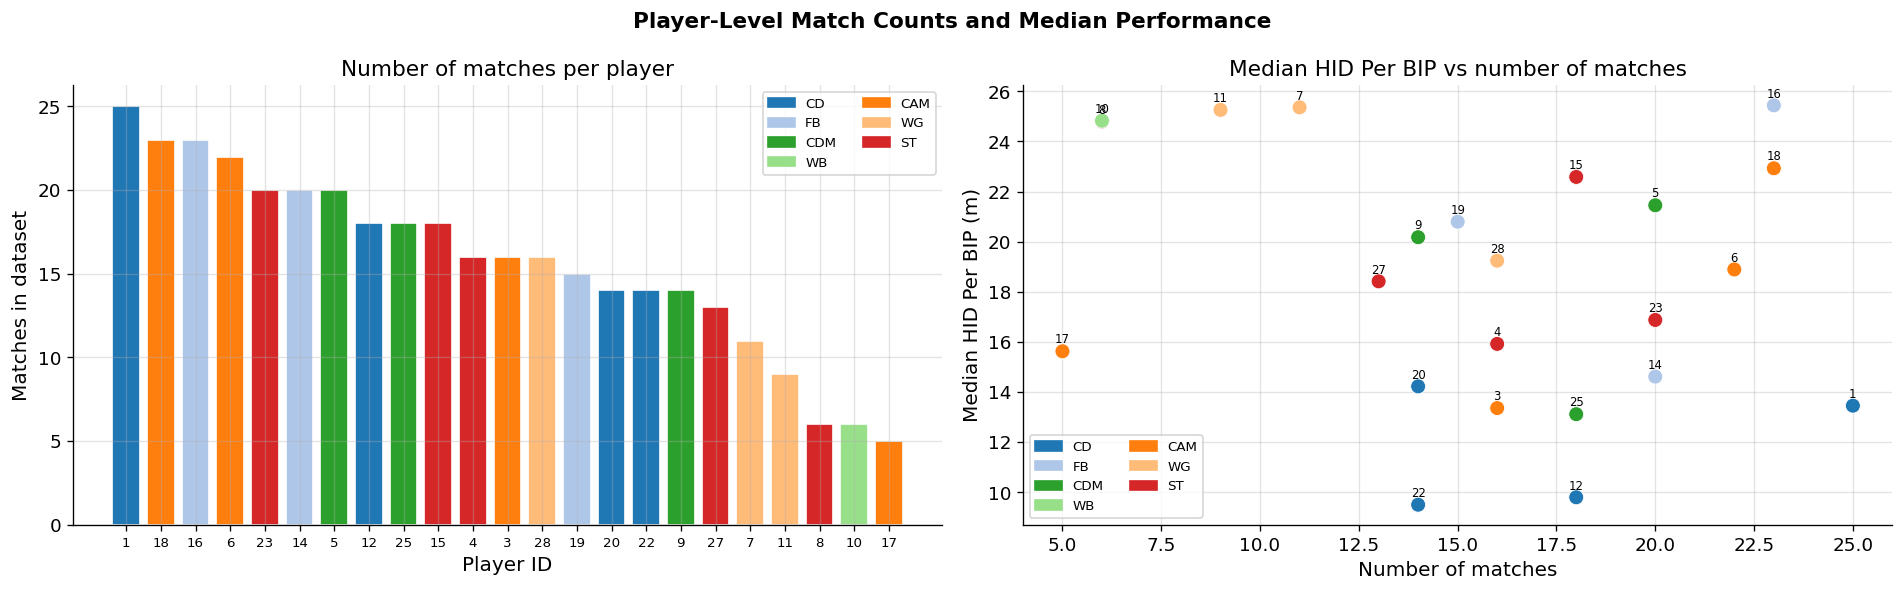

In [9]:
# ── matches per player ─────────────────────────────────────────────────────────
player_match_counts = (
    PERF.groupby('Player ID')
    .agg(
        n_matches=('Match Date', 'count'),
        pos=('Position', 'first'),
        median_hid=(HID_COL, 'median'),
        median_hie=(HIE_COL, 'median'),
        median_min=(MIN_COL, 'median'),
    )
    .sort_values('n_matches', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Player-Level Match Counts and Median Performance', fontsize=13, fontweight='bold')

# Panel 1: matches per player (coloured by position)
ax = axes[0]
bar_colors = [POSITION_COLORS.get(p, C_GREY) for p in player_match_counts['pos']]
bars = ax.bar(player_match_counts['Player ID'].astype(str),
              player_match_counts['n_matches'],
              color=bar_colors, edgecolor='white')
ax.set_xlabel('Player ID')
ax.set_ylabel('Matches in dataset')
ax.set_title('Number of matches per player')
ax.tick_params(axis='x', labelsize=8)
legend_handles = [mpatches.Patch(color=c, label=pos)
                  for pos, c in POSITION_COLORS.items()
                  if pos in player_match_counts['pos'].values]
ax.legend(handles=legend_handles, fontsize=8, ncol=2)

# Panel 2: median HID Per BIP per player (sorted by match count)
ax = axes[1]
ax.scatter(player_match_counts['n_matches'],
           player_match_counts['median_hid'],
           c=[POSITION_COLORS.get(p, C_GREY) for p in player_match_counts['pos']],
           s=80, edgecolors='white', linewidths=0.5, zorder=3)
for _, row in player_match_counts.iterrows():
    ax.annotate(str(int(row['Player ID'])), (row['n_matches'], row['median_hid']),
                fontsize=7, ha='center', va='bottom', xytext=(0, 3),
                textcoords='offset points')
ax.set_xlabel('Number of matches')
ax.set_ylabel('Median HID Per BIP (m)')
ax.set_title('Median HID Per BIP vs number of matches')
ax.legend(handles=legend_handles, fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

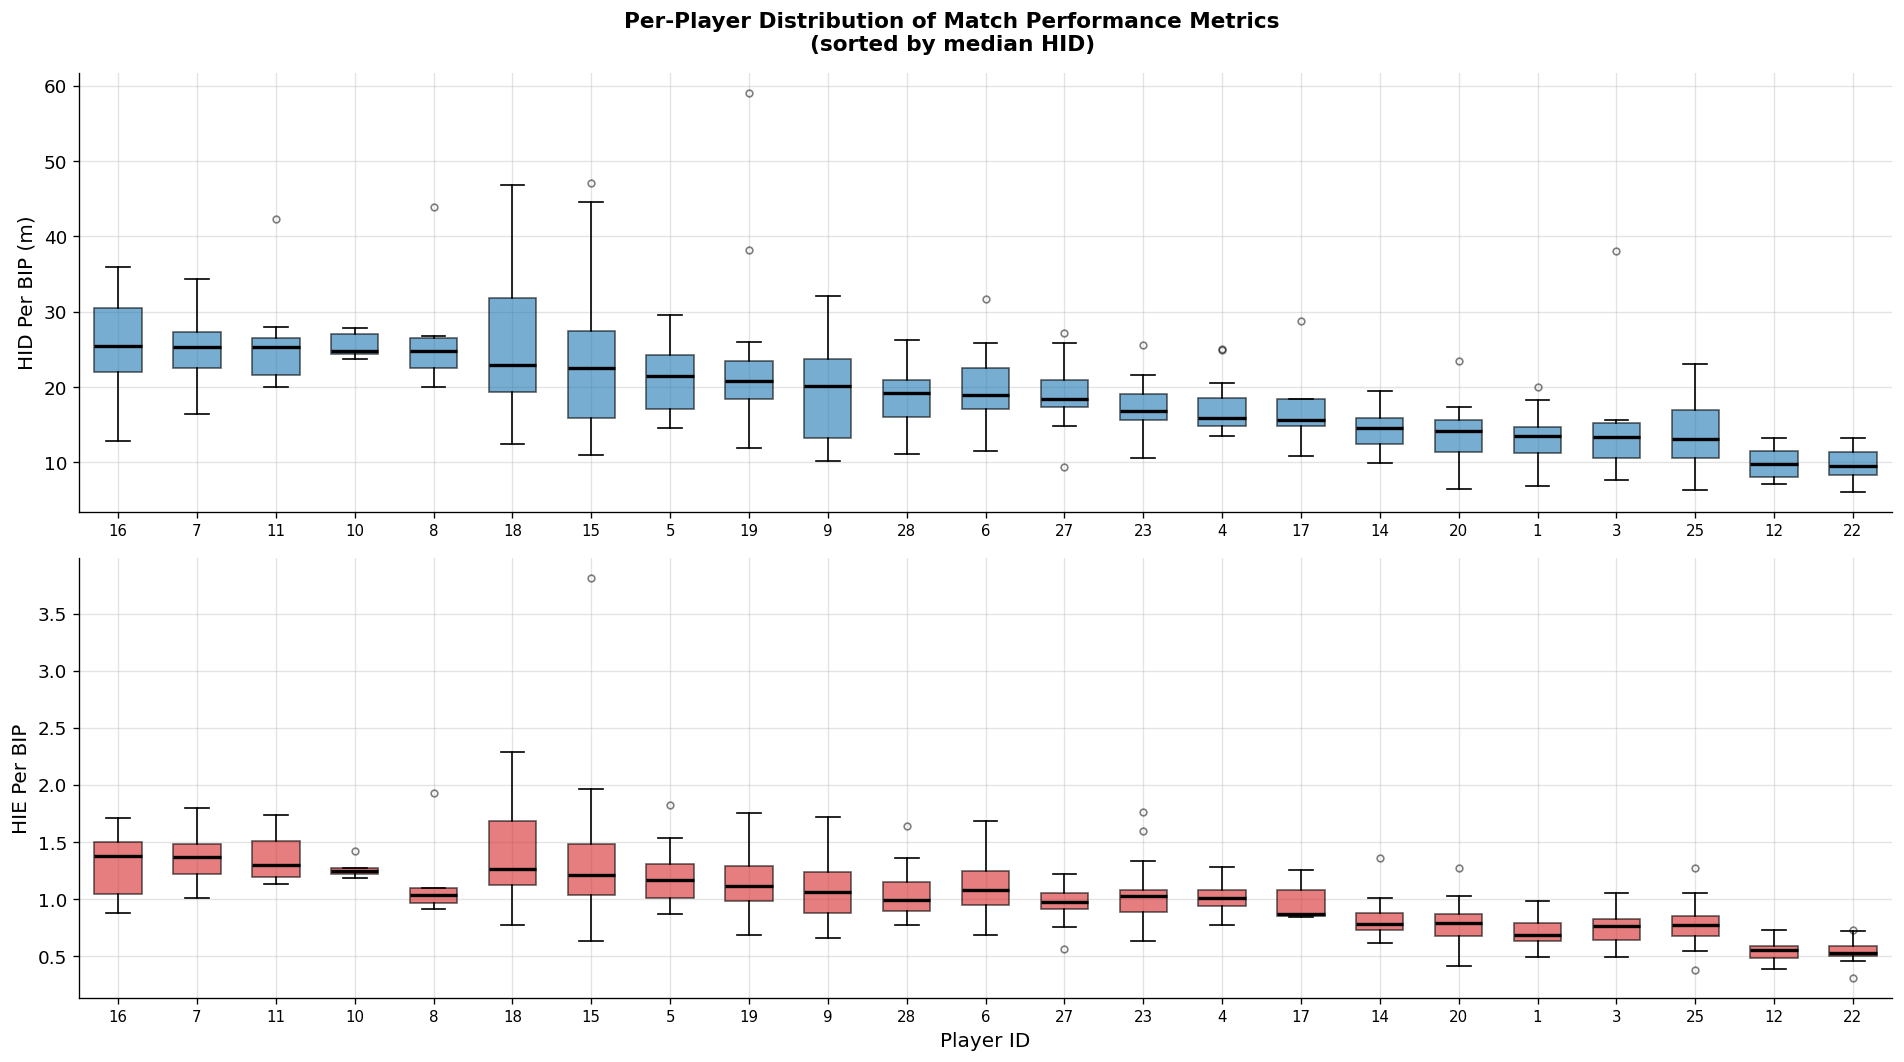

In [10]:
# ── per-player boxplot of HID and HIE ─────────────────────────────────────────
pid_order = (
    PERF.groupby('Player ID')[HID_COL].median()
    .sort_values(ascending=False).index.tolist()
)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Per-Player Distribution of Match Performance Metrics\n(sorted by median HID)',
             fontsize=13, fontweight='bold')

tick_positions = list(range(1, len(pid_order) + 1))
tick_labels = [str(p) for p in pid_order]

for ax, (col, label, color) in zip(axes, [
    (HID_COL, 'HID Per BIP (m)', C_HID),
    (HIE_COL, 'HIE Per BIP',     C_HIE),
]):
    player_groups = [PERF[PERF['Player ID'] == pid][col].dropna() for pid in pid_order]
    bp = ax.boxplot(player_groups, patch_artist=True, widths=0.6,
                    medianprops={'color': 'black', 'lw': 2},
                    flierprops={'marker': 'o', 'ms': 4, 'alpha': 0.5})
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel(label)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=9)

axes[-1].set_xlabel('Player ID')
plt.tight_layout()
plt.show()

---
## 8  Position-Level Analysis

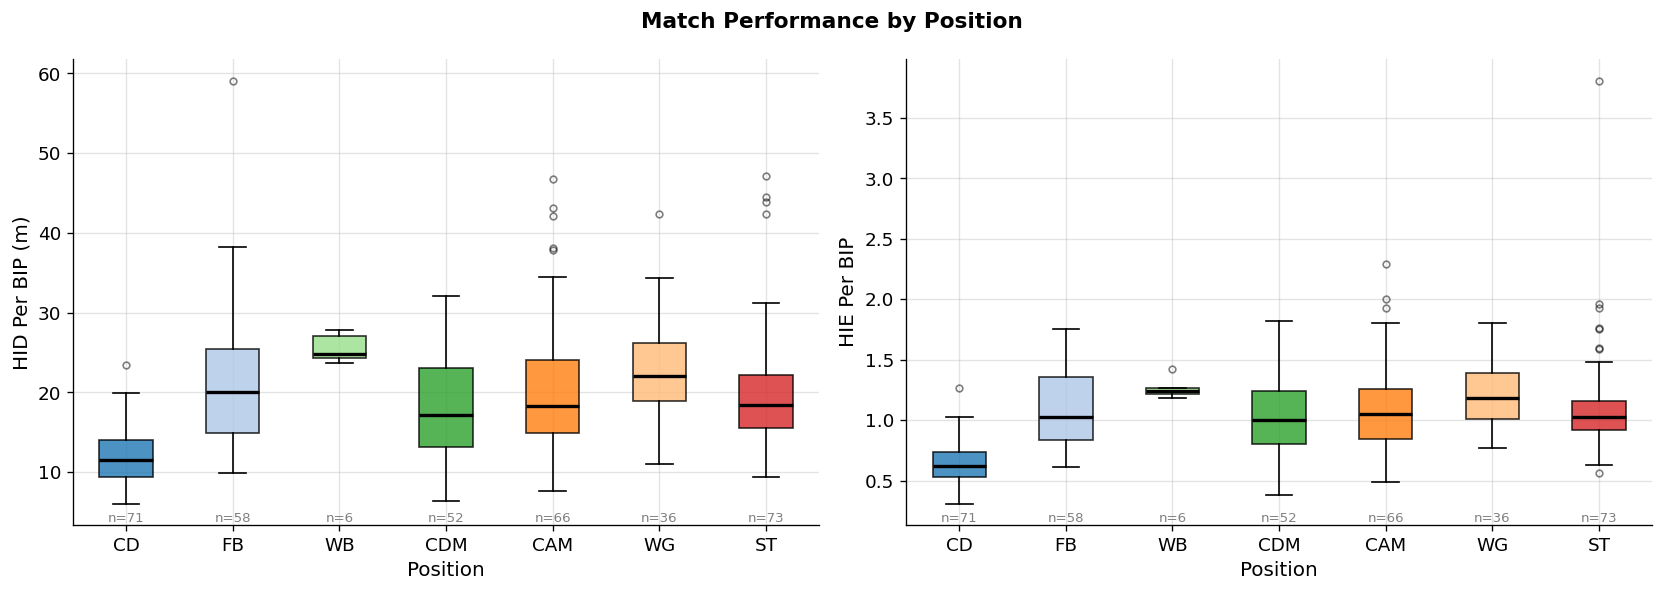

Kruskal–Wallis HID Per BIP across positions: H=111.05, p=0.0000
Kruskal–Wallis HIE Per BIP across positions: H=127.60, p=0.0000


In [11]:
pos_order = ['CD', 'FB', 'WB', 'CDM', 'CAM', 'WG', 'ST']
pos_present = [p for p in pos_order if p in PERF['Position'].values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Match Performance by Position', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, [
    (HID_COL, 'HID Per BIP (m)'),
    (HIE_COL, 'HIE Per BIP'),
]):
    groups = [PERF[PERF['Position'] == pos][col].dropna() for pos in pos_present]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'lw': 2},
                    flierprops={'marker': 'o', 'ms': 4, 'alpha': 0.5})
    for patch, pos in zip(bp['boxes'], pos_present):
        patch.set_facecolor(POSITION_COLORS.get(pos, C_GREY))
        patch.set_alpha(0.8)
    ax.set_xticklabels(pos_present)
    ax.set_xlabel('Position')
    ax.set_ylabel(label)
    # sample sizes
    for k, g in enumerate(groups):
        ax.text(k + 1, ax.get_ylim()[0],
                f'n={len(g)}', ha='center', va='bottom', fontsize=8, color='grey')

plt.tight_layout()
plt.show()

# Kruskal-Wallis across positions
for col, label in [(HID_COL, 'HID Per BIP'), (HIE_COL, 'HIE Per BIP')]:
    groups = [PERF[PERF['Position'] == pos][col].dropna() for pos in pos_present]
    stat, p = stats.kruskal(*[g for g in groups if len(g) >= 3])
    print(f'Kruskal–Wallis {label} across positions: H={stat:.2f}, p={p:.4f}')

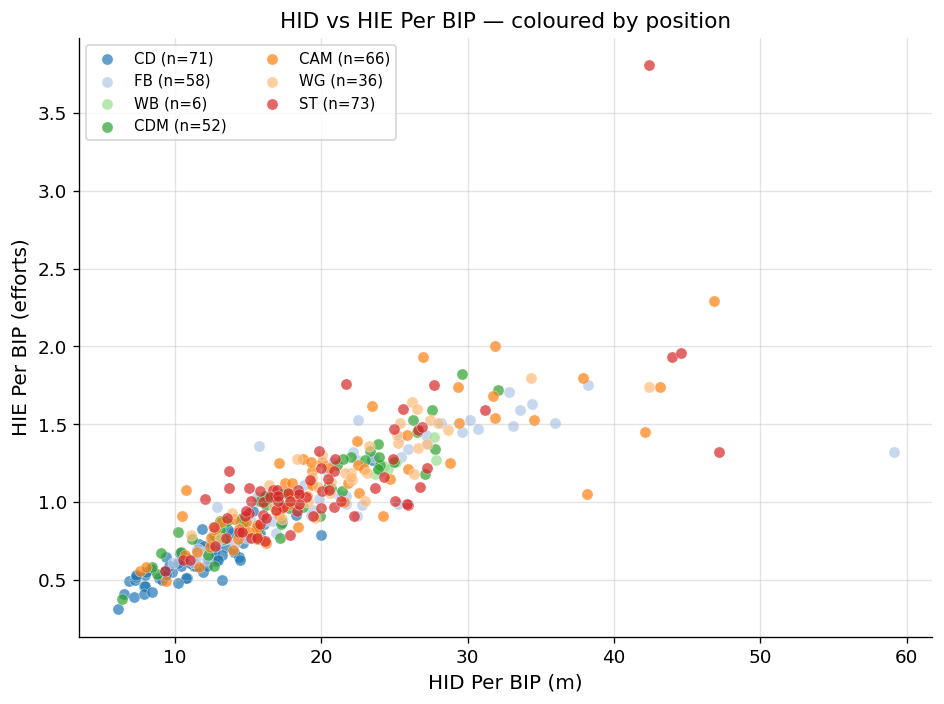

In [12]:
# ── Position scatter: HID vs HIE coloured by position ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for pos in pos_present:
    sub = PERF[PERF['Position'] == pos]
    ax.scatter(sub[HID_COL], sub[HIE_COL],
               color=POSITION_COLORS.get(pos, C_GREY),
               label=f'{pos} (n={len(sub)})', alpha=0.7, s=45,
               edgecolors='white', linewidths=0.3)

ax.set_xlabel('HID Per BIP (m)')
ax.set_ylabel('HIE Per BIP (efforts)')
ax.set_title('HID vs HIE Per BIP — coloured by position')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

---
## 9  Temporal Trends — Performance Over the Season

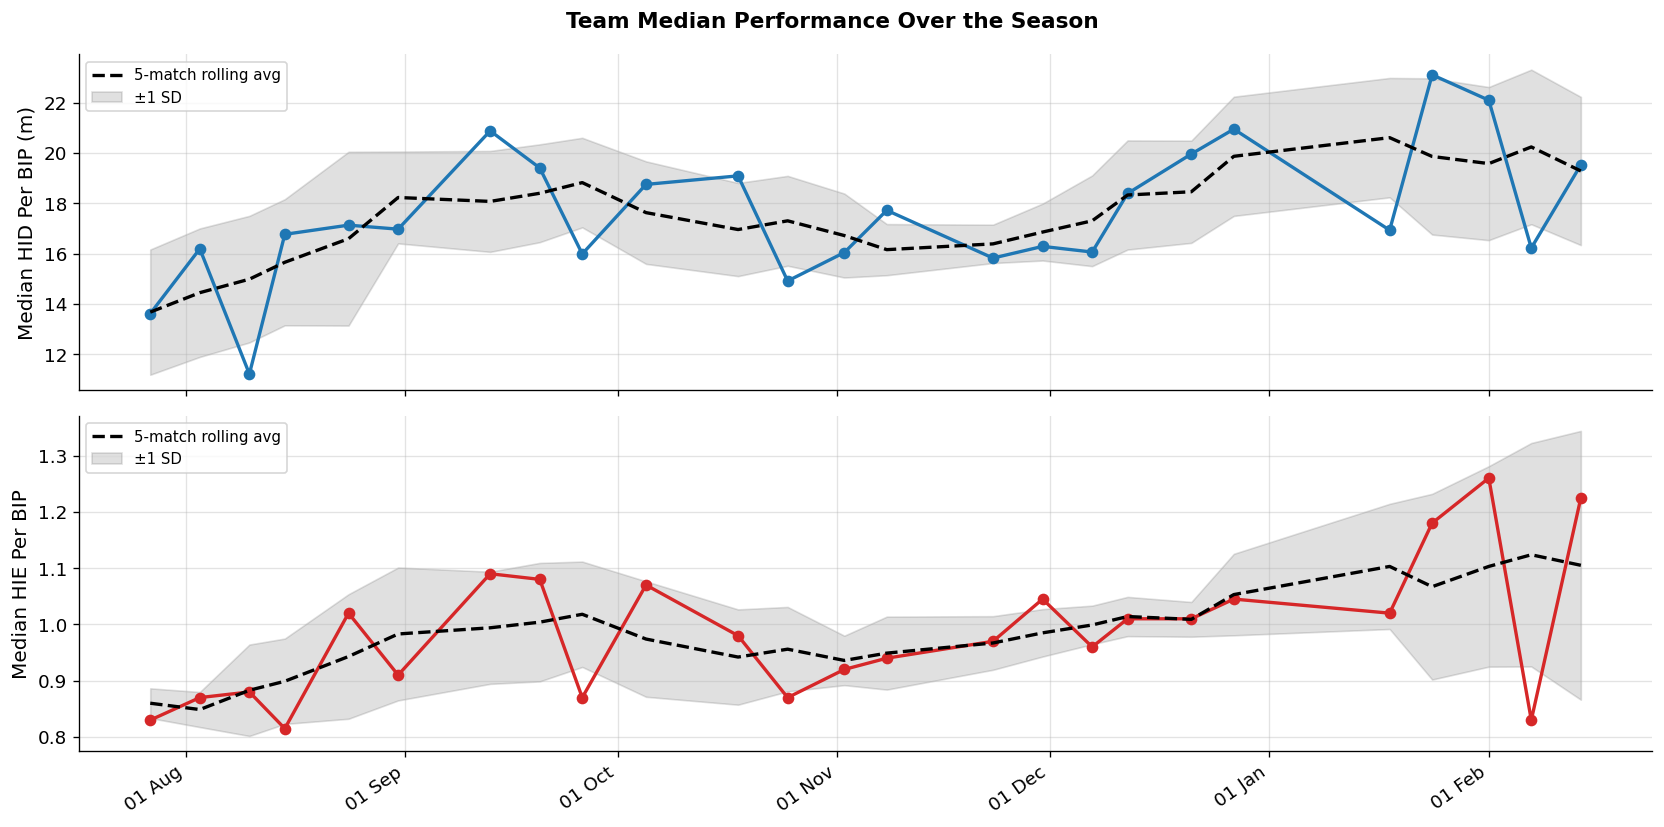

Spearman trend HID Per BIP: rho=0.4515, p=0.0235
Spearman trend HIE Per BIP: rho=0.4741, p=0.0167


In [13]:
# ── Rolling team average over the season ──────────────────────────────────────
match_perf = (
    PERF.groupby('Match Date')[[HID_COL, HIE_COL, MIN_COL]]
    .median()
    .reset_index()
    .sort_values('Match Date')
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Team Median Performance Over the Season', fontsize=13, fontweight='bold')

for ax, (col, label, color) in zip(axes, [
    (HID_COL, 'Median HID Per BIP (m)',  C_HID),
    (HIE_COL, 'Median HIE Per BIP',      C_HIE),
]):
    x = match_perf['Match Date']
    y = match_perf[col]
    ax.plot(x, y, color=color, marker='o', ms=6, lw=2)
    # Rolling 5-match average
    rolling = y.rolling(window=5, min_periods=3, center=True)
    ax.plot(x, rolling.mean(), color='black', lw=2, ls='--', label='5-match rolling avg')
    ax.fill_between(x,
                    rolling.mean() - rolling.std(),
                    rolling.mean() + rolling.std(),
                    alpha=0.12, color='black', label='±1 SD')
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# Spearman trend over time
match_num = np.arange(len(match_perf))
for col, label in [(HID_COL, 'HID Per BIP'), (HIE_COL, 'HIE Per BIP')]:
    r, p = stats.spearmanr(match_num, match_perf[col])
    print(f'Spearman trend {label}: rho={r:.4f}, p={p:.4f}')

---
## 10  Within-Player Consistency

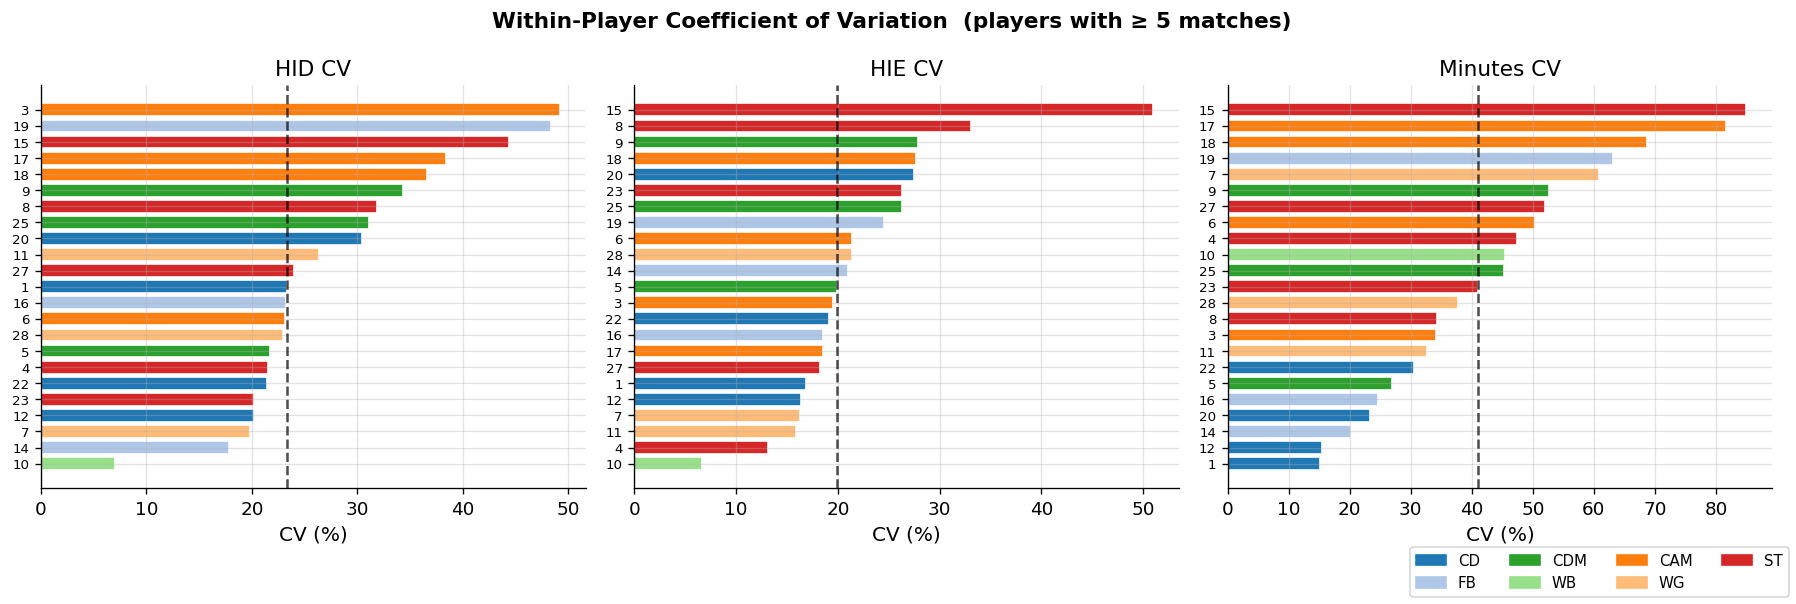

Median CV by metric:
Metric
HID        23.4
HIE        19.9
Minutes    41.0


In [14]:
# Coefficient of Variation (CV) per player — only for players with >= 5 matches
eligible = player_match_counts[player_match_counts['n_matches'] >= 5]['Player ID'].tolist()

cv_data = []
for pid in eligible:
    sub = PERF[PERF['Player ID'] == pid]
    pos = sub['Position'].iloc[0]
    for col, label in [(HID_COL, 'HID'), (HIE_COL, 'HIE'), (MIN_COL, 'Minutes')]:
        d = sub[col].dropna()
        cv_data.append({
            'Player ID': pid, 'Position': pos, 'Metric': label,
            'Mean': d.mean(), 'SD': d.std(), 'CV': d.std() / d.mean() * 100,
            'N': len(d),
        })

cv_df = pd.DataFrame(cv_data)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Within-Player Coefficient of Variation  (players with ≥ 5 matches)',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['HID', 'HIE', 'Minutes']):
    sub = cv_df[cv_df['Metric'] == metric].sort_values('CV')
    bar_col = [POSITION_COLORS.get(p, C_GREY) for p in sub['Position']]
    ax.barh(sub['Player ID'].astype(str), sub['CV'], color=bar_col, edgecolor='white')
    ax.set_xlabel('CV (%)')
    ax.set_title(f'{metric} CV')
    ax.axvline(sub['CV'].median(), color='black', lw=1.5, ls='--', alpha=0.7)
    ax.tick_params(axis='y', labelsize=8)

# Position legend
handles = [mpatches.Patch(color=c, label=p) for p, c in POSITION_COLORS.items()
           if p in cv_df['Position'].values]
fig.legend(handles=handles, fontsize=9, loc='lower right', ncol=4)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

print('Median CV by metric:')
print(cv_df.groupby('Metric')['CV'].median().round(1).to_string())

---
## 11  Match Intensity — The Causal Outcome Y

`Match Intensity Yesterday` is the primary outcome variable for the DTR causal analysis.

**Formula:**
```
Match Intensity = sqrt(HID_perBIP × HIE_perBIP)  ×  sqrt(clip(minutes_played, 15, 90) / 90)
```
- **Geometric mean of HID and HIE**: collapses the two highly-correlated (r = 0.849) per-BIP metrics into one, penalising cases where one metric is very low
- **Minutes clamped to [15, 90]**: the 15-min floor prevents very brief cameo appearances from being penalised too harshly (e.g., an 8-min appearance is treated as 15 min); the 90-min ceiling gives full credit (weight = 1) to anyone who played a full match. The square-root scale further softens the penalty for partial appearances

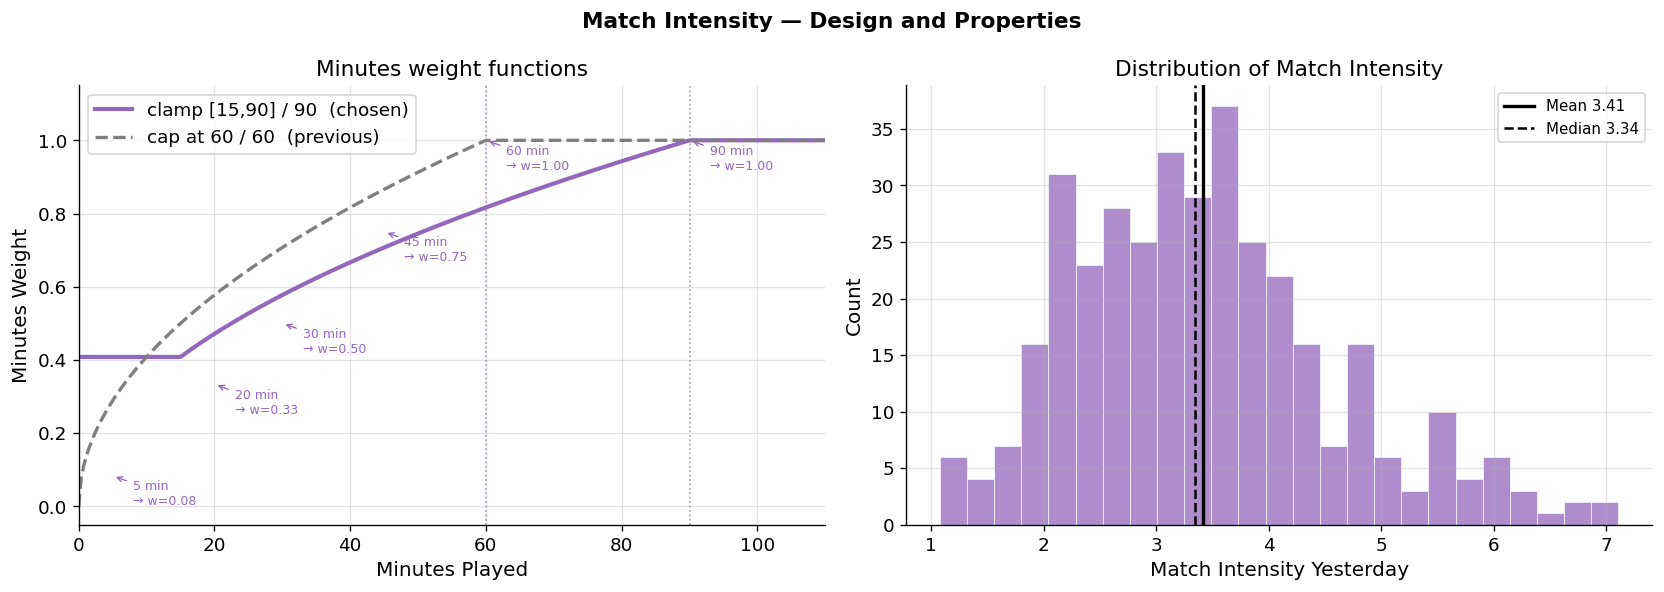

Match Intensity Yesterday statistics:
count    362.0000
mean       3.4121
std        1.1648
min        1.0752
25%        2.5856
50%        3.3437
75%        4.1064
max        7.1096


In [15]:
# ── minutes weight function visualisation ──────────────────────────────────────
mins = np.linspace(0, 110, 300)
weight_new = np.sqrt(np.clip(mins, 15, 90) / 90)  # chosen: clamp [15,90], /90, sqrt
weight_old = np.sqrt(np.minimum(mins, 60) / 60)   # previous: cap at 60, /60, sqrt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Match Intensity — Design and Properties', fontsize=13, fontweight='bold')

# Panel 1: weight functions comparison
ax = axes[0]
ax.plot(mins, weight_new, color=C_MI,  lw=2.5, label='clamp [15,90] / 90  (chosen)')
ax.plot(mins, weight_old, color=C_GREY, lw=2,  ls='--', label='cap at 60 / 60  (previous)')
ax.axvline(60,  color=C_MI,   lw=1, ls=':', alpha=0.7)
ax.axvline(90,  color=C_GREY, lw=1, ls=':', alpha=0.7)
for min_val, lbl in [(5, '5'), (20, '20'), (30, '30'), (45, '45'), (60, '60'), (90, '90')]:
    w60 = min(min_val, 60) / 60
    ax.annotate(f'{min_val} min\n→ w={w60:.2f}',
                xy=(min_val, w60), xytext=(min_val + 3, w60 - 0.08),
                fontsize=7.5, color=C_MI, arrowprops=dict(arrowstyle='->', color=C_MI, lw=0.8))
ax.set_xlabel('Minutes Played')
ax.set_ylabel('Minutes Weight')
ax.set_title('Minutes weight functions')
ax.set_xlim(0, 110)
ax.set_ylim(-0.05, 1.15)
ax.legend()

# Panel 2: distribution of Match Intensity
ax = axes[1]
data_mi = PERF[MI_COL].dropna()
ax.hist(data_mi, bins=25, color=C_MI, alpha=0.75, edgecolor='white', linewidth=0.5)
ax.axvline(data_mi.mean(),   color='black', lw=2,   ls='-',  label=f'Mean {data_mi.mean():.2f}')
ax.axvline(data_mi.median(), color='black', lw=1.5, ls='--', label=f'Median {data_mi.median():.2f}')
ax.set_xlabel('Match Intensity Yesterday')
ax.set_ylabel('Count')
ax.set_title('Distribution of Match Intensity')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Match Intensity Yesterday statistics:')
print(PERF[MI_COL].describe().round(4).to_string())

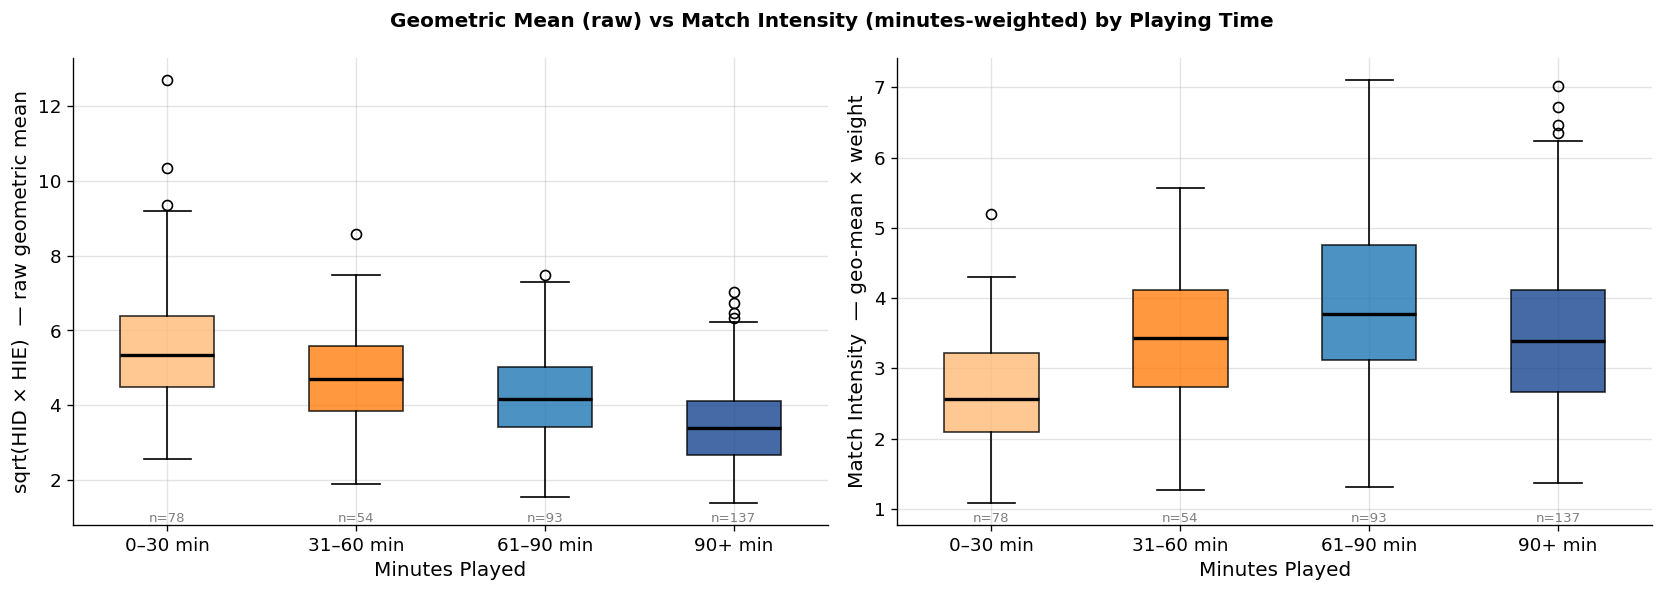

Median geometric mean and Match Intensity by playing-time bin:
  0–30 min      n= 78  GeoMean=5.35  MI=2.57  ratio=0.48
  31–60 min     n= 54  GeoMean=4.70  MI=3.43  ratio=0.73
  61–90 min     n= 93  GeoMean=4.16  MI=3.77  ratio=0.91
  90+ min       n=137  GeoMean=3.39  MI=3.39  ratio=1.00


In [16]:
# ── compare raw geo-mean vs Match Intensity by playing-time bin ────────────────
PERF['GeoMean'] = np.sqrt(PERF[HID_COL] * PERF[HIE_COL])
bin_order = ['0–30 min', '31–60 min', '61–90 min', '90+ min']
colors_bins = ['#ffbb78', '#ff7f0e', '#1f77b4', '#174590']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Geometric Mean (raw) vs Match Intensity (minutes-weighted) by Playing Time',
             fontsize=12, fontweight='bold')

for ax, (col, label) in zip(axes, [
    ('GeoMean', 'sqrt(HID × HIE)  — raw geometric mean'),
    (MI_COL,    'Match Intensity  — geo-mean × weight'),
]):
    groups = [PERF[PERF['Minutes Bin'] == b][col].dropna() for b in bin_order]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'lw': 2})
    for patch, c in zip(bp['boxes'], colors_bins):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    ax.set_xticklabels(bin_order)
    ax.set_xlabel('Minutes Played')
    ax.set_ylabel(label)
    for k, g in enumerate(groups):
        ax.text(k + 1, ax.get_ylim()[0], f'n={len(g)}',
                ha='center', va='bottom', fontsize=8, color='grey')

plt.tight_layout()
plt.show()

# Show how minutes weight dampens the substitute inflation
print('Median geometric mean and Match Intensity by playing-time bin:')
for b in bin_order:
    sub = PERF[PERF['Minutes Bin'] == b]
    gm  = sub['GeoMean'].median()
    mi  = sub[MI_COL].median()
    w   = mi / gm if gm > 0 else float('nan')
    print(f'  {b:<12}  n={len(sub):3d}  GeoMean={gm:.2f}  MI={mi:.2f}  ratio={w:.2f}')

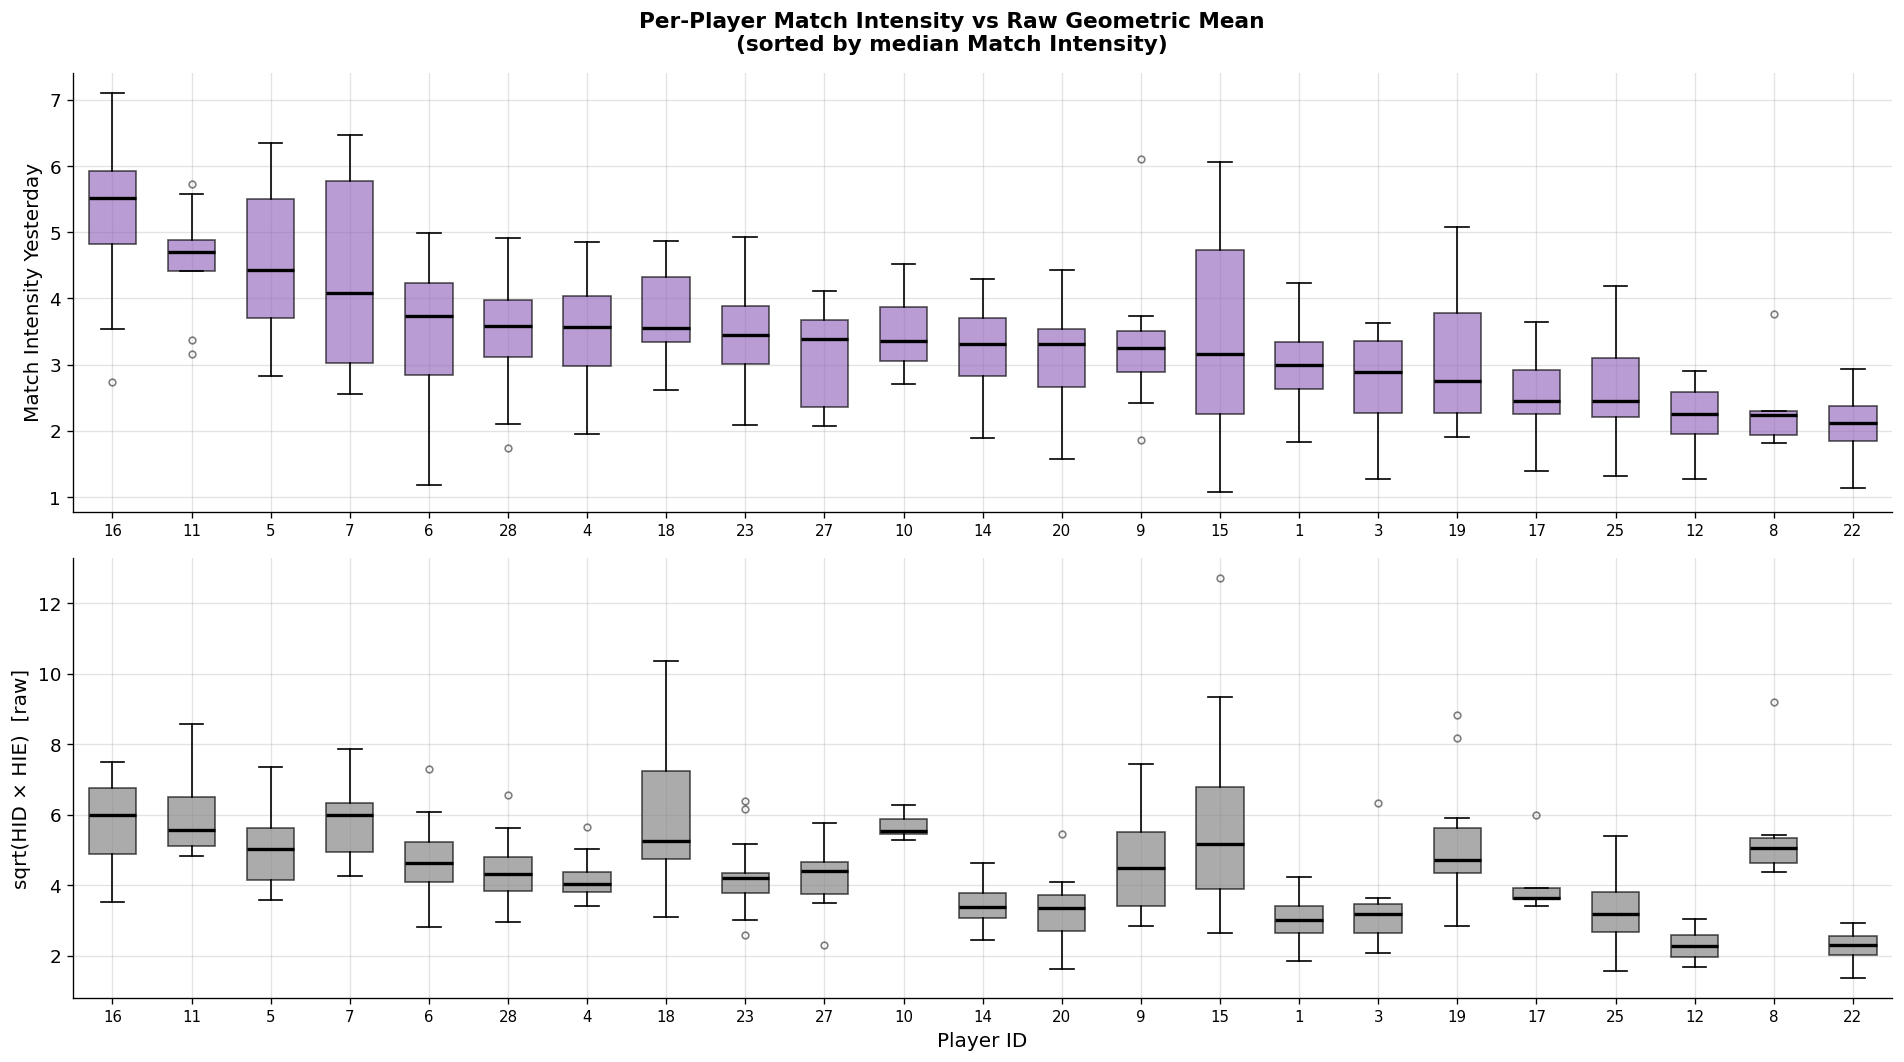

In [17]:
# ── per-player Match Intensity boxplot ────────────────────────────────────────
pid_mi_order = (
    PERF.groupby('Player ID')[MI_COL].median()
    .sort_values(ascending=False).index.tolist()
)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Per-Player Match Intensity vs Raw Geometric Mean\n(sorted by median Match Intensity)',
             fontsize=13, fontweight='bold')

tick_positions = list(range(1, len(pid_mi_order) + 1))
tick_labels    = [str(p) for p in pid_mi_order]

for ax, (col, label, color) in zip(axes, [
    (MI_COL,    'Match Intensity Yesterday', C_MI),
    ('GeoMean', 'sqrt(HID × HIE)  [raw]',   C_GREY),
]):
    groups = [PERF[PERF['Player ID'] == pid][col].dropna() for pid in pid_mi_order]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.6,
                    medianprops={'color': 'black', 'lw': 2},
                    flierprops={'marker': 'o', 'ms': 4, 'alpha': 0.5})
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_ylabel(label)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=9)

axes[-1].set_xlabel('Player ID')
plt.tight_layout()
plt.show()

---
## 12  Summary

In [18]:
print('=' * 65)
print('MATCH ANALYSIS SUMMARY')
print('=' * 65)

n_matches = PERF['Match Date'].nunique()
n_players = PERF['Player ID'].nunique()
n_obs     = len(PERF)

r_hid_hie, p_hid_hie = stats.pearsonr(PERF[HID_COL], PERF[HIE_COL])
r_hid_min, p_hid_min = stats.pearsonr(PERF[HID_COL], PERF[MIN_COL])
r_hie_min, p_hie_min = stats.pearsonr(PERF[HIE_COL], PERF[MIN_COL])
r_mi_hid,  p_mi_hid  = stats.pearsonr(PERF[MI_COL],  PERF[HID_COL])
r_mi_hie,  p_mi_hie  = stats.pearsonr(PERF[MI_COL],  PERF[HIE_COL])
r_mi_min,  p_mi_min  = stats.pearsonr(PERF[MI_COL],  PERF[MIN_COL])

print(f'Matches:                     {n_matches}')
print(f'Players with data:           {n_players} / 28')
print(f'Player-match observations:   {n_obs}')
print()
print(f'HID Per BIP:       mean {PERF[HID_COL].mean():.1f}  (SD {PERF[HID_COL].std():.1f})')
print(f'HIE Per BIP:       mean {PERF[HIE_COL].mean():.3f}   (SD {PERF[HIE_COL].std():.3f})')
print(f'Minutes:           mean {PERF[MIN_COL].mean():.1f}  (SD {PERF[MIN_COL].std():.1f})')
print(f'Match Intensity Y: mean {PERF[MI_COL].mean():.2f}   (SD {PERF[MI_COL].std():.2f})')
print()
print('Correlations:')
print(f'  HID vs HIE:            r={r_hid_hie:+.3f}  p={p_hid_hie:.2e}  strong positive')
print(f'  HID vs Minutes:        r={r_hid_min:+.3f}  p={p_hid_min:.2e}  moderate negative')
print(f'  HIE vs Minutes:        r={r_hie_min:+.3f}  p={p_hie_min:.2e}  moderate negative')
print(f'  Match Intensity vs HID: r={r_mi_hid:+.3f}  p={p_mi_hid:.2e}')
print(f'  Match Intensity vs HIE: r={r_mi_hie:+.3f}  p={p_mi_hie:.2e}')
print(f'  Match Intensity vs Min: r={r_mi_min:+.3f}  p={p_mi_min:.2e}')
print()
print('Match Intensity formula:')
print('  Y = sqrt(HID_perBIP × HIE_perBIP) × sqrt(min(minutes, 60) / 60)')
print()
print('Key findings:')
print('  - HID and HIE are highly correlated (r=0.849): same underlying construct.')
print('  - Substitutes inflate raw per-BIP; the 60-min cap dampens this cleanly.')
print('  - Match Intensity reorders players relative to raw geo-mean: starters')
print('    who play full games rise, short-stint substitutes fall.')
print('  - Substantial between-player variability (CV ≈ 30-50%) persists,')
print('    confirming the need for individualised DTR models.')
print('=' * 65)

MATCH ANALYSIS SUMMARY
Matches:                     25
Players with data:           23 / 28
Player-match observations:   362

HID Per BIP:       mean 18.8  (SD 7.8)
HIE Per BIP:       mean 1.018   (SD 0.373)
Minutes:           mean 68.2  (SD 31.9)
Match Intensity Y: mean 3.41   (SD 1.16)

Correlations:
  HID vs HIE:            r=+0.849  p=5.42e-102  strong positive
  HID vs Minutes:        r=-0.499  p=3.12e-24  moderate negative
  HIE vs Minutes:        r=-0.486  p=8.10e-23  moderate negative
  Match Intensity vs HID: r=+0.554  p=1.79e-30
  Match Intensity vs HIE: r=+0.585  p=1.12e-34
  Match Intensity vs Min: r=+0.301  p=4.85e-09

Match Intensity formula:
  Y = sqrt(HID_perBIP × HIE_perBIP) × sqrt(min(minutes, 60) / 60)

Key findings:
  - HID and HIE are highly correlated (r=0.849): same underlying construct.
  - Substitutes inflate raw per-BIP; the 60-min cap dampens this cleanly.
  - Match Intensity reorders players relative to raw geo-mean: starters
    who play full games rise, sh